In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split, ConcatDataset
from torchvision import datasets, transforms, models
import time
import sys
import matplotlib.pyplot as plt
import pandas as pd
import os
import copy
import warnings

warnings.filterwarnings("ignore")
os.environ["PYTHONWARNINGS"] = "ignore"

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
USE_AMP = True
DATASET_NAME = 'MNIST'

os.makedirs("experiments/graphs", exist_ok=True)
os.makedirs("experiments/models", exist_ok=True)

def get_data_loaders(batch_size, pin_memory):
    transform = transforms.Compose([
        transforms.Resize((32, 32)),
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,))
    ])

    if DATASET_NAME == 'FashionMNIST':
        train_part = datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
        test_part = datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)
    else:
        train_part = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
        test_part = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

    full_dataset = ConcatDataset([train_part, test_part])
    total_size = len(full_dataset)
    train_size = int(0.70 * total_size)
    val_size = int(0.10 * total_size)
    test_size = total_size - train_size - val_size

    train_set, val_set, test_set = random_split(full_dataset, [train_size, val_size, test_size])

    train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True, pin_memory=pin_memory, num_workers=2)
    val_loader = DataLoader(val_set, batch_size=batch_size, shuffle=False, pin_memory=pin_memory, num_workers=2)
    test_loader = DataLoader(test_set, batch_size=batch_size, shuffle=False, pin_memory=pin_memory, num_workers=2)

    return train_loader, val_loader, test_loader

def get_model(model_name):
    if model_name == 'ResNet-18':
        model = models.resnet18(weights=None)
    else:
        model = models.resnet50(weights=None)

    model.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
    num_ftrs = model.fc.in_features
    model.fc = nn.Linear(num_ftrs, 10)
    return model.to(DEVICE)

def plot_graphs(history, title_prefix):
    epochs = range(1, len(history['train_acc']) + 1)

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, history['train_acc'], label='Train Acc')
    plt.plot(epochs, history['val_acc'], label='Val Acc')
    plt.title(f'{title_prefix} Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy (%)')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, history['train_loss'], label='Train Loss')
    plt.plot(epochs, history['val_loss'], label='Val Loss')
    plt.title(f'{title_prefix} Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    clean_title = title_prefix.replace(" ", "_").replace(".", "p")
    plt.savefig(f"experiments/graphs/{clean_title}.png")
    plt.close()

def train_experiment(config):
    model_name, bs, opt_name, lr, pin_mem, epochs = config

    run_id = f"{model_name}_BS{bs}_{opt_name}_LR{lr}_Pin{pin_mem}_Ep{epochs}"

    train_loader, val_loader, test_loader = get_data_loaders(bs, pin_mem)
    model = get_model(model_name)

    if opt_name == 'SGD':
        optimizer = optim.SGD(model.parameters(), lr=lr, momentum=0.9)
    else:
        optimizer = optim.Adam(model.parameters(), lr=lr)

    criterion = nn.CrossEntropyLoss()
    scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)

    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    best_val_acc = 0.0
    best_model_wts = copy.deepcopy(model.state_dict())

    start_time = time.time()

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        for images, labels in train_loader:
            images, labels = images.to(DEVICE, non_blocking=pin_mem), labels.to(DEVICE, non_blocking=pin_mem)
            optimizer.zero_grad()

            with torch.cuda.amp.autocast(enabled=USE_AMP):
                outputs = model(images)
                loss = criterion(outputs, labels)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            running_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        epoch_train_loss = running_loss / total
        epoch_train_acc = 100 * correct / total

        model.eval()
        val_loss = 0.0
        val_correct = 0
        val_total = 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(DEVICE, non_blocking=pin_mem), labels.to(DEVICE, non_blocking=pin_mem)
                outputs = model(images)
                loss = criterion(outputs, labels)

                val_loss += loss.item() * images.size(0)
                _, predicted = torch.max(outputs.data, 1)
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()

        epoch_val_loss = val_loss / val_total
        epoch_val_acc = 100 * val_correct / val_total

        history['train_loss'].append(epoch_train_loss)
        history['train_acc'].append(epoch_train_acc)
        history['val_loss'].append(epoch_val_loss)
        history['val_acc'].append(epoch_val_acc)

        if epoch_val_acc > best_val_acc:
            best_val_acc = epoch_val_acc
            best_model_wts = copy.deepcopy(model.state_dict())
            torch.save(model.state_dict(), f"experiments/models/best_{run_id}.pth")

    total_time = time.time() - start_time

    plot_graphs(history, run_id)

    model.load_state_dict(best_model_wts)

    model.eval()
    test_correct = 0
    test_total = 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(DEVICE, non_blocking=pin_mem), labels.to(DEVICE, non_blocking=pin_mem)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            test_total += labels.size(0)
            test_correct += (predicted == labels).sum().item()

    test_acc = 100 * test_correct / test_total
    return test_acc, total_time

if __name__ == "__main__":
    print(f"Device: {DEVICE} | Dataset: {DATASET_NAME}")
    print("-" * 80)
    print(f"{'Model':<12} {'BS':<4} {'Opt':<6} {'LR':<8} {'Pin':<6} {'Eps':<4} | {'Test Acc':<8} {'Time(s)':<8}")
    print("-" * 80)

    table_rows = [
        ('ResNet-18', 16, 'SGD', 0.001),
        ('ResNet-18', 16, 'SGD', 0.0001),
        ('ResNet-18', 16, 'Adam', 0.001),
        ('ResNet-18', 16, 'Adam', 0.0001),
        ('ResNet-18', 32, 'SGD', 0.001),
        ('ResNet-18', 32, 'Adam', 0.001),

        ('ResNet-50', 16, 'SGD', 0.001),
        ('ResNet-50', 16, 'SGD', 0.0001),
        ('ResNet-50', 16, 'Adam', 0.001),
        ('ResNet-50', 16, 'Adam', 0.0001),
        ('ResNet-50', 32, 'SGD', 0.001),
        ('ResNet-50', 32, 'Adam', 0.001),
    ]

    epoch_variations = [3, 5]
    pin_variations = [False, True]

    all_results = []

    for eps in epoch_variations:
        for pin in pin_variations:
            for row in table_rows:
                model_name, bs, opt, lr = row
                config = (model_name, bs, opt, lr, pin, eps)

                acc, time_taken = train_experiment(config)

                print(f"{model_name:<12} {bs:<4} {opt:<6} {lr:<8} {str(pin):<6} {eps:<4} | {acc:<8.2f} {time_taken:<8.1f}")

                all_results.append({
                    'Model': model_name, 'BatchSize': bs, 'Optimizer': opt,
                    'LR': lr, 'PinMemory': pin, 'Epochs': eps,
                    'TestAccuracy': acc, 'Time': time_taken
                })

    df = pd.DataFrame(all_results)
    df.to_csv("experiments/experiment_results.csv", index=False)
    print("\nAll experiments completed. Results, models, and graphs saved in 'experiments/' folder.")

Device: cuda | Dataset: MNIST
--------------------------------------------------------------------------------
Model        BS   Opt    LR       Pin    Eps  | Test Acc Time(s) 
--------------------------------------------------------------------------------


100%|██████████| 9.91M/9.91M [00:00<00:00, 38.0MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.07MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 10.1MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.78MB/s]


ResNet-18    16   SGD    0.001    False  3    | 98.62    136.3   
ResNet-18    16   SGD    0.0001   False  3    | 98.35    134.6   
ResNet-18    16   Adam   0.001    False  3    | 98.89    153.1   
ResNet-18    16   Adam   0.0001   False  3    | 98.87    152.8   
ResNet-18    32   SGD    0.001    False  3    | 98.78    72.8    
ResNet-18    32   Adam   0.001    False  3    | 98.65    82.9    
ResNet-50    16   SGD    0.001    False  3    | 98.43    271.1   
ResNet-50    16   SGD    0.0001   False  3    | 97.15    272.2   
ResNet-50    16   Adam   0.001    False  3    | 97.89    311.6   
ResNet-50    16   Adam   0.0001   False  3    | 97.27    314.4   
ResNet-50    32   SGD    0.001    False  3    | 98.40    139.1   
ResNet-50    32   Adam   0.001    False  3    | 96.98    158.8   
ResNet-18    16   SGD    0.001    True   3    | 98.99    128.4   
ResNet-18    16   SGD    0.0001   True   3    | 98.13    127.3   
ResNet-18    16   Adam   0.001    True   3    | 98.40    147.4   
ResNet-18 

In [15]:
import pandas as pd
df = pd.read_csv('experiment_results.csv')
df  # Simply call the variable name

,Model,BatchSize,Optimizer,LR,PinMemory,Epochs,TestAccuracy,Time
0,ResNet-18,16,SGD,0.0010,False,3,98.621429,136.259313
1,ResNet-18,16,SGD,0.0001,False,3,98.350000,134.591042
2,ResNet-18,16,Adam,0.0010,False,3,98.885714,153.122881
3,ResNet-18,16,Adam,0.0001,False,3,98.871429,152.799572
4,ResNet-18,32,SGD,0.0010,False,3,98.778571,72.846557
5,ResNet-18,32,Adam,0.0010,False,3,98.650000,82.896293
6,ResNet-50,16,SGD,0.0010,False,3,98.428571,271.074144
7,ResNet-50,16,SGD,0.0001,False,3,97.150000,272.211811
8,ResNet-50,16,Adam,0.0010,False,3,97.892857,311.582053
9,ResNet-50,16,Adam,0.0001,False,3,97.271429,314.447509


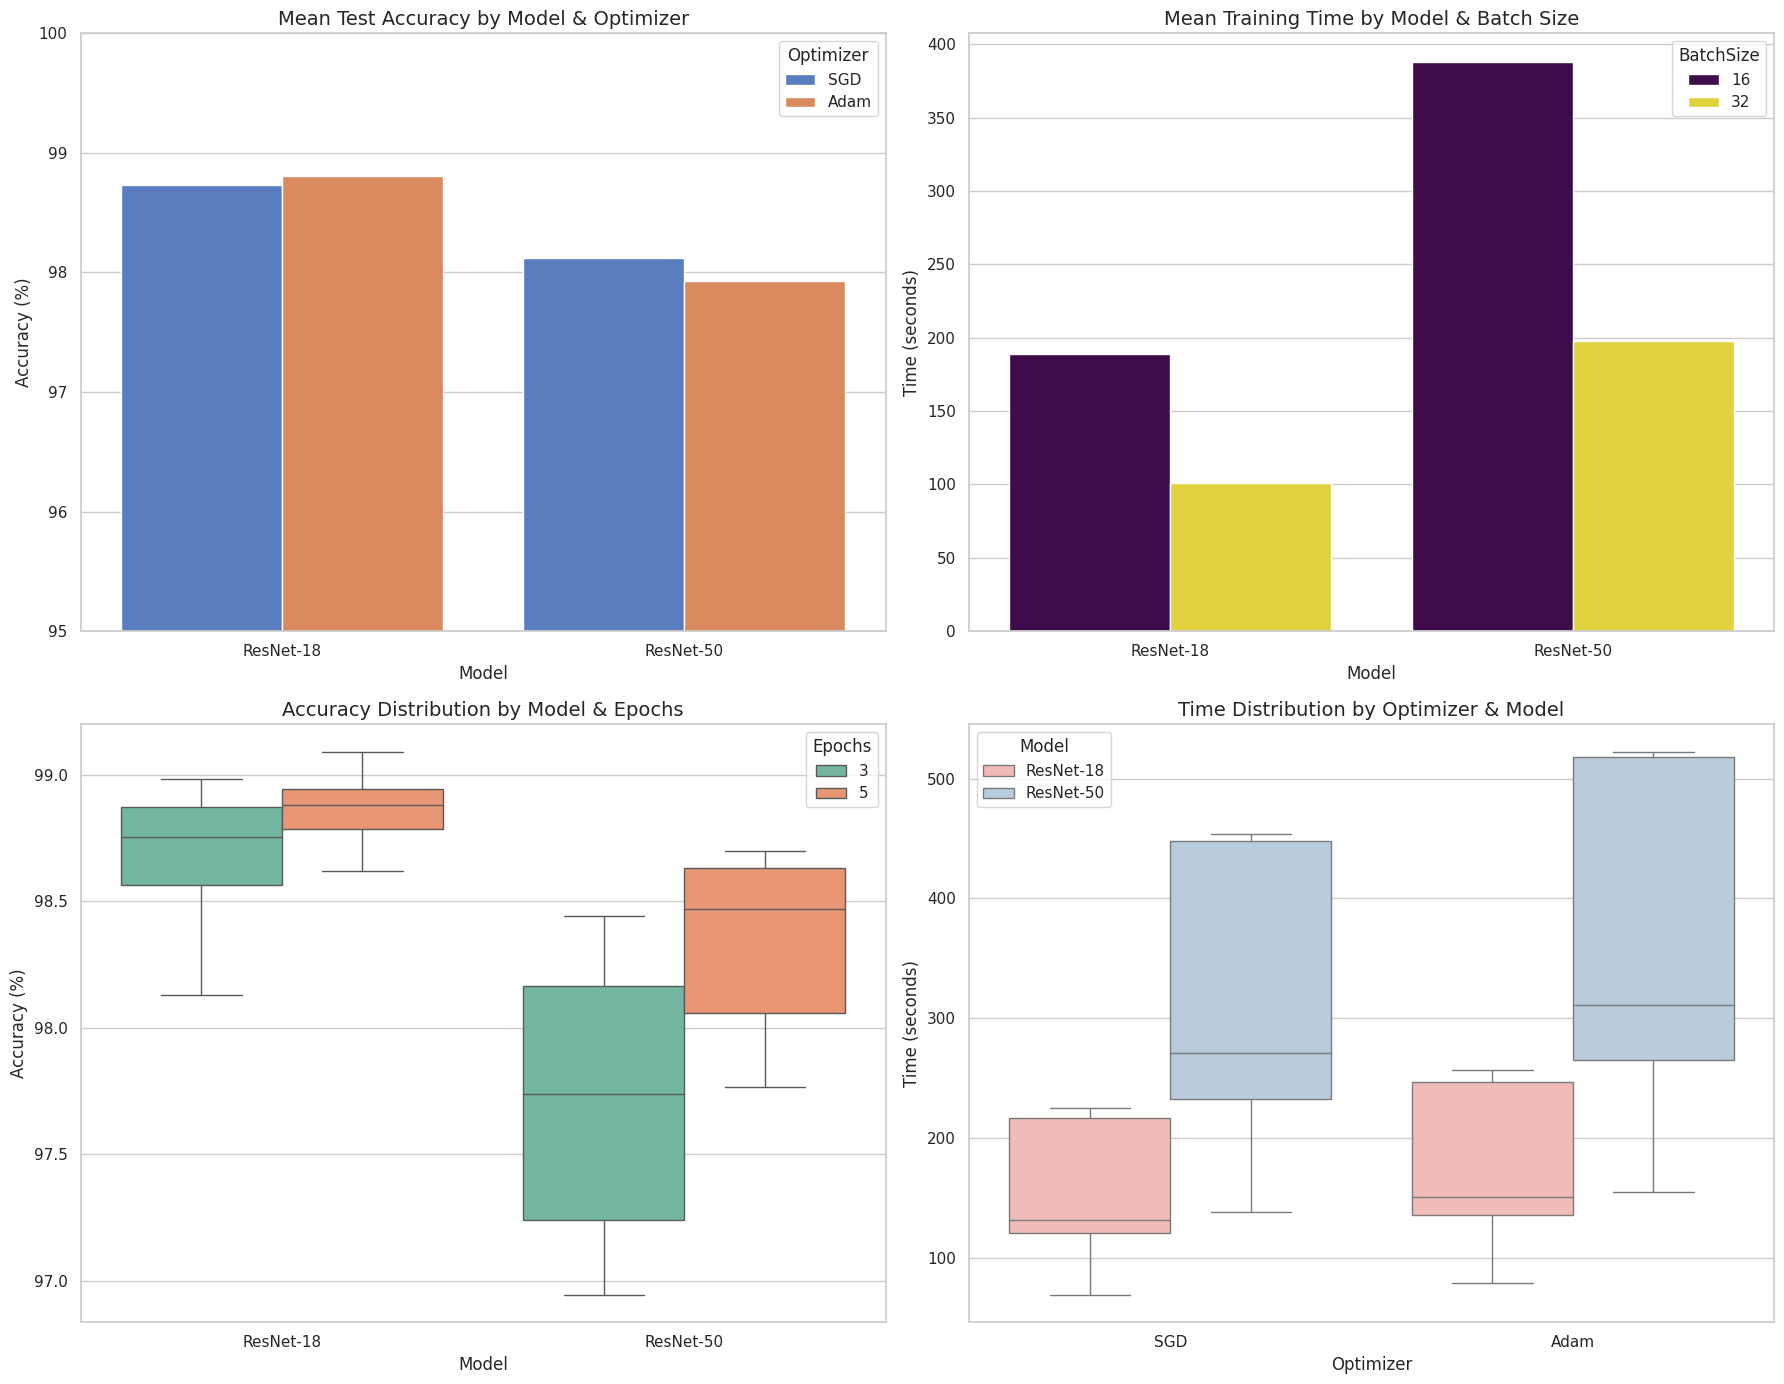

--- Summary Statistics ---
                               TestAccuracy        Time
Model     BatchSize Optimizer                          
ResNet-18 16        Adam          98.812500  200.989087
                    SGD           98.673214  176.178064
          32        Adam          98.791071  107.667037
                    SGD           98.844643   94.991746
ResNet-50 16        Adam          98.035714  415.648458
                    SGD           97.977679  360.291743
          32        Adam          97.721429  210.396215
                    SGD           98.419643  184.897965


In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


df = pd.read_csv("experiment_results.csv")


sns.set_theme(style="whitegrid")


fig, axes = plt.subplots(2, 2, figsize=(18, 14))




sns.barplot(ax=axes[0, 0], data=df, x='Model', y='TestAccuracy', hue='Optimizer', palette='muted', errorbar=None)
axes[0, 0].set_title('Mean Test Accuracy by Model & Optimizer', fontsize=14)
axes[0, 0].set_ylabel('Accuracy (%)')
axes[0, 0].set_ylim(95, 100)


sns.barplot(ax=axes[0, 1], data=df, x='Model', y='Time', hue='BatchSize', palette='viridis', errorbar=None)
axes[0, 1].set_title('Mean Training Time by Model & Batch Size', fontsize=14)
axes[0, 1].set_ylabel('Time (seconds)')




sns.boxplot(ax=axes[1, 0], data=df, x='Model', y='TestAccuracy', hue='Epochs', palette='Set2')
axes[1, 0].set_title('Accuracy Distribution by Model & Epochs', fontsize=14)
axes[1, 0].set_ylabel('Accuracy (%)')


sns.boxplot(ax=axes[1, 1], data=df, x='Optimizer', y='Time', hue='Model', palette='Pastel1')
axes[1, 1].set_title('Time Distribution by Optimizer & Model', fontsize=14)
axes[1, 1].set_ylabel('Time (seconds)')


plt.tight_layout()
plt.savefig('combined_performance_analysis.png')
plt.show()


print("--- Summary Statistics ---")
print(df.groupby(['Model', 'BatchSize', 'Optimizer'])[['TestAccuracy', 'Time']].mean())

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split, ConcatDataset
from torchvision import datasets, transforms, models
import time
import sys
import matplotlib.pyplot as plt
import pandas as pd
import os
import copy
import warnings

warnings.filterwarnings("ignore")
os.environ["PYTHONWARNINGS"] = "ignore"

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
USE_AMP = True
DATASET_NAME = 'FashionMNIST'

os.makedirs("experiments/graphs", exist_ok=True)
os.makedirs("experiments/models", exist_ok=True)

def get_data_loaders(batch_size, pin_memory):
    transform = transforms.Compose([
        transforms.Resize((32, 32)),
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,))
    ])

    if DATASET_NAME == 'FashionMNIST':
        train_part = datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
        test_part = datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)
    else:
        train_part = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
        test_part = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

    full_dataset = ConcatDataset([train_part, test_part])
    total_size = len(full_dataset)
    train_size = int(0.70 * total_size)
    val_size = int(0.10 * total_size)
    test_size = total_size - train_size - val_size

    train_set, val_set, test_set = random_split(full_dataset, [train_size, val_size, test_size])

    train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True, pin_memory=pin_memory, num_workers=2)
    val_loader = DataLoader(val_set, batch_size=batch_size, shuffle=False, pin_memory=pin_memory, num_workers=2)
    test_loader = DataLoader(test_set, batch_size=batch_size, shuffle=False, pin_memory=pin_memory, num_workers=2)

    return train_loader, val_loader, test_loader

def get_model(model_name):
    if model_name == 'ResNet-18':
        model = models.resnet18(weights=None)
    else:
        model = models.resnet50(weights=None)

    model.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
    num_ftrs = model.fc.in_features
    model.fc = nn.Linear(num_ftrs, 10)
    return model.to(DEVICE)

def plot_graphs(history, title_prefix):
    epochs = range(1, len(history['train_acc']) + 1)

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, history['train_acc'], label='Train Acc')
    plt.plot(epochs, history['val_acc'], label='Val Acc')
    plt.title(f'{title_prefix} Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy (%)')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, history['train_loss'], label='Train Loss')
    plt.plot(epochs, history['val_loss'], label='Val Loss')
    plt.title(f'{title_prefix} Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    clean_title = title_prefix.replace(" ", "_").replace(".", "p")
    plt.savefig(f"experiments/graphs/{clean_title}.png")
    plt.close()

def train_experiment(config):
    model_name, bs, opt_name, lr, pin_mem, epochs = config

    run_id = f"{model_name}_BS{bs}_{opt_name}_LR{lr}_Pin{pin_mem}_Ep{epochs}"

    train_loader, val_loader, test_loader = get_data_loaders(bs, pin_mem)
    model = get_model(model_name)

    if opt_name == 'SGD':
        optimizer = optim.SGD(model.parameters(), lr=lr, momentum=0.9)
    else:
        optimizer = optim.Adam(model.parameters(), lr=lr)

    criterion = nn.CrossEntropyLoss()
    scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)

    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    best_val_acc = 0.0
    best_model_wts = copy.deepcopy(model.state_dict())

    start_time = time.time()

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        for images, labels in train_loader:
            images, labels = images.to(DEVICE, non_blocking=pin_mem), labels.to(DEVICE, non_blocking=pin_mem)
            optimizer.zero_grad()

            with torch.cuda.amp.autocast(enabled=USE_AMP):
                outputs = model(images)
                loss = criterion(outputs, labels)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            running_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        epoch_train_loss = running_loss / total
        epoch_train_acc = 100 * correct / total

        model.eval()
        val_loss = 0.0
        val_correct = 0
        val_total = 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(DEVICE, non_blocking=pin_mem), labels.to(DEVICE, non_blocking=pin_mem)
                outputs = model(images)
                loss = criterion(outputs, labels)

                val_loss += loss.item() * images.size(0)
                _, predicted = torch.max(outputs.data, 1)
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()

        epoch_val_loss = val_loss / val_total
        epoch_val_acc = 100 * val_correct / val_total

        history['train_loss'].append(epoch_train_loss)
        history['train_acc'].append(epoch_train_acc)
        history['val_loss'].append(epoch_val_loss)
        history['val_acc'].append(epoch_val_acc)

        if epoch_val_acc > best_val_acc:
            best_val_acc = epoch_val_acc
            best_model_wts = copy.deepcopy(model.state_dict())
            torch.save(model.state_dict(), f"experiments/models/best_{run_id}.pth")

    total_time = time.time() - start_time

    plot_graphs(history, run_id)

    model.load_state_dict(best_model_wts)

    model.eval()
    test_correct = 0
    test_total = 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(DEVICE, non_blocking=pin_mem), labels.to(DEVICE, non_blocking=pin_mem)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            test_total += labels.size(0)
            test_correct += (predicted == labels).sum().item()

    test_acc = 100 * test_correct / test_total
    return test_acc, total_time

if __name__ == "__main__":
    print(f"Device: {DEVICE} | Dataset: {DATASET_NAME}")
    print("-" * 80)
    print(f"{'Model':<12} {'BS':<4} {'Opt':<6} {'LR':<8} {'Pin':<6} {'Eps':<4} | {'Test Acc':<8} {'Time(s)':<8}")
    print("-" * 80)

    table_rows = [
        ('ResNet-18', 16, 'SGD', 0.001),
        ('ResNet-18', 16, 'SGD', 0.0001),
        ('ResNet-18', 16, 'Adam', 0.001),
        ('ResNet-18', 16, 'Adam', 0.0001),
        ('ResNet-18', 32, 'SGD', 0.001),
        ('ResNet-18', 32, 'Adam', 0.001),

        ('ResNet-50', 16, 'SGD', 0.001),
        ('ResNet-50', 16, 'SGD', 0.0001),
        ('ResNet-50', 16, 'Adam', 0.001),
        ('ResNet-50', 16, 'Adam', 0.0001),
        ('ResNet-50', 32, 'SGD', 0.001),
        ('ResNet-50', 32, 'Adam', 0.001),
    ]

    epoch_variations = [3, 5]
    pin_variations = [False, True]

    all_results = []

    for eps in epoch_variations:
        for pin in pin_variations:
            for row in table_rows:
                model_name, bs, opt, lr = row
                config = (model_name, bs, opt, lr, pin, eps)

                acc, time_taken = train_experiment(config)

                print(f"{model_name:<12} {bs:<4} {opt:<6} {lr:<8} {str(pin):<6} {eps:<4} | {acc:<8.2f} {time_taken:<8.1f}")

                all_results.append({
                    'Model': model_name, 'BatchSize': bs, 'Optimizer': opt,
                    'LR': lr, 'PinMemory': pin, 'Epochs': eps,
                    'TestAccuracy': acc, 'Time': time_taken
                })

    df = pd.DataFrame(all_results)
    df.to_csv("experiments/experiment_results.csv", index=False)
    print("\nAll experiments completed. Results, models, and graphs saved in 'experiments/' folder.")

Device: cuda | Dataset: FashionMNIST
--------------------------------------------------------------------------------
Model        BS   Opt    LR       Pin    Eps  | Test Acc Time(s) 
--------------------------------------------------------------------------------


100%|██████████| 26.4M/26.4M [00:01<00:00, 17.1MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 273kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 5.10MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 13.1MB/s]


ResNet-18    16   SGD    0.001    False  3    | 89.61    152.7   
ResNet-18    16   SGD    0.0001   False  3    | 87.69    150.8   
ResNet-18    16   Adam   0.001    False  3    | 90.21    170.3   
ResNet-18    16   Adam   0.0001   False  3    | 89.66    171.3   
ResNet-18    32   SGD    0.001    False  3    | 89.52    85.0    
ResNet-18    32   Adam   0.001    False  3    | 89.06    94.8    
ResNet-50    16   SGD    0.001    False  3    | 88.16    309.4   
ResNet-50    16   SGD    0.0001   False  3    | 82.67    309.7   
ResNet-50    16   Adam   0.001    False  3    | 85.91    353.0   
ResNet-50    16   Adam   0.0001   False  3    | 86.34    356.7   
ResNet-50    32   SGD    0.001    False  3    | 86.99    161.7   
ResNet-50    32   Adam   0.001    False  3    | 86.49    179.9   
ResNet-18    16   SGD    0.001    True   3    | 89.03    145.1   
ResNet-18    16   SGD    0.0001   True   3    | 88.51    145.3   
ResNet-18    16   Adam   0.001    True   3    | 89.27    166.1   
ResNet-18 

In [16]:
import pandas as pd
df = pd.read_csv('Fashion_MNIST.csv')
df  # Simply call the variable name

,Model,BatchSize,Optimizer,LR,PinMemory,Epochs,TestAccuracy,Time
0,ResNet-18,16,SGD,0.0010,False,3,89.614286,152.721538
1,ResNet-18,16,SGD,0.0001,False,3,87.692857,150.841816
2,ResNet-18,16,Adam,0.0010,False,3,90.207143,170.319200
3,ResNet-18,16,Adam,0.0001,False,3,89.657143,171.319020
4,ResNet-18,32,SGD,0.0010,False,3,89.521429,84.958380
5,ResNet-18,32,Adam,0.0010,False,3,89.064286,94.751390
6,ResNet-50,16,SGD,0.0010,False,3,88.157143,309.407250
7,ResNet-50,16,SGD,0.0001,False,3,82.671429,309.739778
8,ResNet-50,16,Adam,0.0010,False,3,85.914286,353.011680
9,ResNet-50,16,Adam,0.0001,False,3,86.335714,356.697570


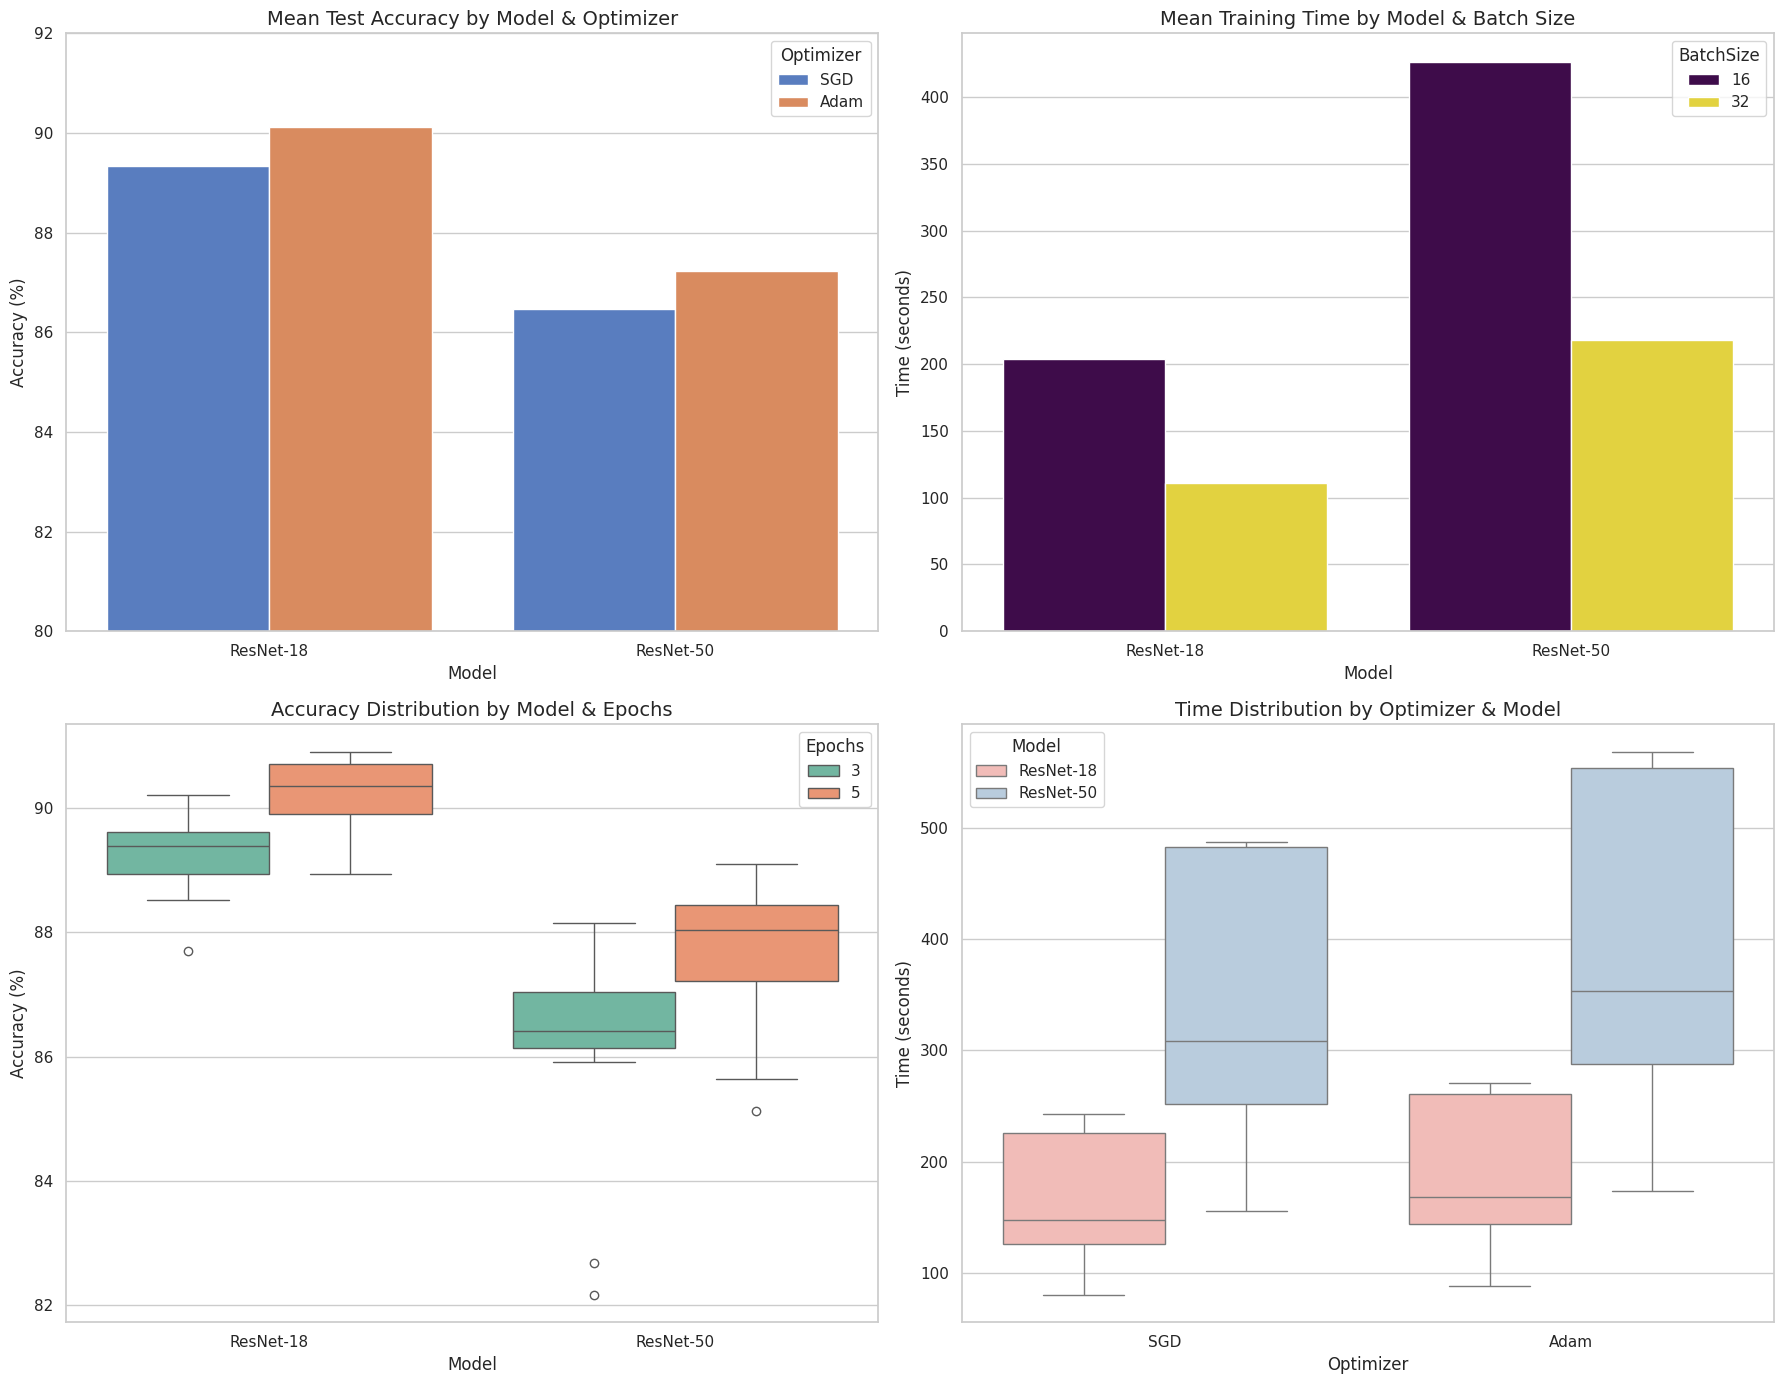

--- Summary Statistics ---
                               TestAccuracy        Time
Model     BatchSize Optimizer                          
ResNet-18 16        Adam          90.049107  216.834746
                    SGD           89.175893  191.185245
          32        Adam          90.273214  117.648122
                    SGD           89.642857  103.967684
ResNet-50 16        Adam          87.220536  455.808541
                    SGD           85.869643  397.067311
          32        Adam          87.241071  231.725245
                    SGD           87.657143  204.689449


In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the correct file
df = pd.read_csv("Fashion_MNIST.csv")

# Setting the visual theme
sns.set_theme(style="whitegrid")

# Create the figure with 2 rows and 2 columns
fig, axes = plt.subplots(2, 2, figsize=(18, 14))

# --- BAR CHARTS ---

# Plot 1: Mean Test Accuracy (Model vs Optimizer)
# Adjusted ylim to 80-92 to match your actual data range
sns.barplot(ax=axes[0, 0], data=df, x='Model', y='TestAccuracy', hue='Optimizer', palette='muted', errorbar=None)
axes[0, 0].set_title('Mean Test Accuracy by Model & Optimizer', fontsize=14)
axes[0, 0].set_ylabel('Accuracy (%)')
axes[0, 0].set_ylim(80, 92)

# Plot 2: Mean Training Time (Model vs Batch Size)
sns.barplot(ax=axes[0, 1], data=df, x='Model', y='Time', hue='BatchSize', palette='viridis', errorbar=None)
axes[0, 1].set_title('Mean Training Time by Model & Batch Size', fontsize=14)
axes[0, 1].set_ylabel('Time (seconds)')

# --- BOXPLOTS ---

# Plot 3: Accuracy Distribution (Model vs Epochs)
sns.boxplot(ax=axes[1, 0], data=df, x='Model', y='TestAccuracy', hue='Epochs', palette='Set2')
axes[1, 0].set_title('Accuracy Distribution by Model & Epochs', fontsize=14)
axes[1, 0].set_ylabel('Accuracy (%)')

# Plot 4: Training Time Variance (Optimizer vs Model)
sns.boxplot(ax=axes[1, 1], data=df, x='Optimizer', y='Time', hue='Model', palette='Pastel1')
axes[1, 1].set_title('Time Distribution by Optimizer & Model', fontsize=14)
axes[1, 1].set_ylabel('Time (seconds)')

# Adjust layout and save
plt.tight_layout()
plt.savefig('corrected_performance_analysis.png')
plt.show()

# Display mean summary for quick reference
print("--- Summary Statistics ---")
print(df.groupby(['Model', 'BatchSize', 'Optimizer'])[['TestAccuracy', 'Time']].mean())

In [ ]:
!pip install matplotlib pandas tqdm fvcore

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torchvision.models import resnet18, resnet50
from fvcore.nn import FlopCountAnalysis
import time
import os
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

BATCH_SIZE = 16
LR = 0.001
EPOCHS = 5
DEVICE = torch.device("cpu")
RESULTS_DIR = "results_cpu"
os.makedirs(RESULTS_DIR, exist_ok=True)

def get_model(model_name):
    if model_name == "ResNet-18":
        model = resnet18(num_classes=10)
        model.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
    else:
        model = resnet50(num_classes=10)
        model.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
    return model

def run_cpu_experiment(model_name, opt_name):
    print(f"\n--- Running: {model_name} | {opt_name} ---")

    transform = transforms.Compose([
        transforms.Resize(32),
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,))
    ])

    # 1. Load both sets and combine into 70,000 images
    full_train = torchvision.datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
    full_test = torchvision.datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)
    full_dataset = torch.utils.data.ConcatDataset([full_train, full_test])

    # 2. Define 70-10-20 sizes
    total_size = len(full_dataset)
    train_size = int(0.70 * total_size)
    val_size = int(0.10 * total_size)
    test_size = total_size - train_size - val_size

    # 3. Random split
    train_ds, val_ds, test_ds = torch.utils.data.random_split(
        full_dataset, [train_size, val_size, test_size],
        generator=torch.Generator().manual_seed(42)
    )

    trainloader = torch.utils.data.DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
    valloader = torch.utils.data.DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
    testloader = torch.utils.data.DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

    model = get_model(model_name).to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr=LR) if opt_name == "SGD" else optim.Adam(model.parameters(), lr=LR)

    dummy_input = torch.randn(2, 1, 32, 32)
    flops = FlopCountAnalysis(model, dummy_input).total()

    history = {'train_loss': [], 'val_acc': []}
    start_time = time.time()

    for epoch in range(EPOCHS):
        model.train()
        running_loss = 0.0
        pbar = tqdm(trainloader, desc=f"Epoch {epoch+1}/{EPOCHS}")
        for inputs, labels in pbar:
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

        model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for inputs, labels in valloader:
                inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
                outputs = model(inputs)
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        val_accuracy = 100 * correct / total
        history['train_loss'].append(running_loss / len(trainloader))
        history['val_acc'].append(val_accuracy)
        print(f"Val Acc: {val_accuracy:.2f}%")

    total_time = (time.time() - start_time) * 1000
    avg_epoch_time = total_time / EPOCHS

    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for inputs, labels in testloader:
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    test_acc = 100 * correct / total

    prefix = f"{model_name}_{opt_name}_CPU"
    torch.save(model.state_dict(), f"{RESULTS_DIR}/{prefix}_weights.pth")

    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1)
    plt.plot(history['train_loss'])
    plt.title(f'{prefix} Loss')
    plt.subplot(1,2,2)
    plt.plot(history['val_acc'])
    plt.title(f'{prefix} Accuracy')
    plt.savefig(f"{RESULTS_DIR}/{prefix}_graphs.png")
    plt.close()

    return test_acc, avg_epoch_time, flops

models = ["ResNet-18", "ResNet-50"]
optimizers = ["SGD", "Adam"]
stats = []

for m in models:
    for o in optimizers:
        acc, t, f = run_cpu_experiment(m, o)
        stats.append({"Model": m, "Optimizer": o, "Accuracy": acc, "Epoch_Time_ms": t, "GFLOPs": f/1e9})

pd.DataFrame(stats).to_csv(f"{RESULTS_DIR}/cpu_summary.csv", index=False)
print("\n--- CPU RUN COMPLETE ---")


--- Running: ResNet-18 | SGD ---


100%|██████████| 26.4M/26.4M [00:03<00:00, 7.59MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 117kB/s]
100%|██████████| 4.42M/4.42M [00:02<00:00, 2.12MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 10.6MB/s]
Unsupported operator aten::add_ encountered 28 time(s)
Unsupported operator aten::max_pool2d encountered 1 time(s)
Epoch 1/5: 100%|██████████| 3063/3063 [10:39<00:00,  4.79it/s]


Val Acc: 85.83%


Epoch 2/5: 100%|██████████| 3063/3063 [10:16<00:00,  4.97it/s]


Val Acc: 88.03%


...

Val Acc: 85.30%


Epoch 4/5: 100%|██████████| 3063/3063 [22:29<00:00,  2.27it/s]


Val Acc: 86.50%


Epoch 5/5: 100%|██████████| 3063/3063 [20:42<00:00,  2.47it/s]


Val Acc: 87.64%

--- CPU RUN COMPLETE ---


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torchvision.models import resnet18, resnet50
from fvcore.nn import FlopCountAnalysis
import time
import os
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
from google.colab import drive

drive.mount('/content/drive')

BATCH_SIZE = 16
LR = 0.001
EPOCHS = 5
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
RESULTS_DIR = "/content/drive/MyDrive/FashionMNIST_Results_GPU"
os.makedirs(RESULTS_DIR, exist_ok=True)

def get_model(model_name):
    if model_name == "ResNet-18":
        model = resnet18(num_classes=10)
        model.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
    else:
        model = resnet50(num_classes=10)
        model.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
    return model

def run_experiment(model_name, opt_name):
    print(f"\n--- Running: {model_name} | {opt_name} | {DEVICE} ---")

    transform = transforms.Compose([
        transforms.Resize(32),
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,))
    ])

    full_train = torchvision.datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
    full_test = torchvision.datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)
    full_dataset = torch.utils.data.ConcatDataset([full_train, full_test])

    total_size = len(full_dataset)
    train_size = int(0.70 * total_size)
    val_size = int(0.10 * total_size)
    test_size = total_size - train_size - val_size

    train_ds, val_ds, test_ds = torch.utils.data.random_split(
        full_dataset, [train_size, val_size, test_size],
        generator=torch.Generator().manual_seed(42)
    )

    trainloader = torch.utils.data.DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
    valloader = torch.utils.data.DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
    testloader = torch.utils.data.DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

    model = get_model(model_name).to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr=LR) if opt_name == "SGD" else optim.Adam(model.parameters(), lr=LR)

    dummy_input = torch.randn(2, 1, 32, 32).to(DEVICE)
    flops = FlopCountAnalysis(model, dummy_input).total()

    history = {'train_loss': [], 'val_acc': []}
    start_time = time.time()

    for epoch in range(EPOCHS):
        model.train()
        running_loss = 0.0
        pbar = tqdm(trainloader, desc=f"Epoch {epoch+1}/{EPOCHS}")
        for inputs, labels in pbar:
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

        model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for inputs, labels in valloader:
                inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
                outputs = model(inputs)
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        val_acc = 100 * correct / total
        history['train_loss'].append(running_loss / len(trainloader))
        history['val_acc'].append(val_acc)
        print(f"Val Acc: {val_acc:.2f}%")

    avg_epoch_time = ((time.time() - start_time) / EPOCHS) * 1000

    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for inputs, labels in testloader:
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    test_acc = 100 * correct / total

    prefix = f"{model_name}_{opt_name}_{DEVICE}"
    torch.save(model.state_dict(), f"{RESULTS_DIR}/{prefix}_weights.pth")

    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1)
    plt.plot(history['train_loss'])
    plt.title('Loss')
    plt.subplot(1,2,2)
    plt.plot(history['val_acc'])
    plt.title('Accuracy')
    plt.savefig(f"{RESULTS_DIR}/{prefix}_graphs.png")
    plt.close()

    return test_acc, avg_epoch_time, flops

models = ["ResNet-18", "ResNet-50"]
optimizers = ["SGD", "Adam"]
stats = []

for m in models:
    for o in optimizers:
        acc, t, f = run_experiment(m, o)
        stats.append({
            "Compute": str(DEVICE),
            "Model": m,
            "Optimizer": o,
            "Test_Accuracy": acc,
            "Train_Time_ms": t,
            "FLOPs": f
        })

df = pd.DataFrame(stats)
df.to_csv(f"{RESULTS_DIR}/gpu_summary.csv", index=False)
print("\n--- GPU RUN COMPLETE ---")

Mounted at /content/drive

--- Running: ResNet-18 | SGD | cuda ---


100%|██████████| 26.4M/26.4M [00:00<00:00, 116MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 3.24MB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 62.7MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 13.1MB/s]
Epoch 1/5: 100%|██████████| 3063/3063 [00:48<00:00, 62.61it/s]


Val Acc: 85.43%


Epoch 2/5: 100%|██████████| 3063/3063 [00:46<00:00, 65.64it/s]


Val Acc: 86.87%


...

Val Acc: 83.87%


Epoch 4/5: 100%|██████████| 3063/3063 [01:48<00:00, 28.22it/s]


Val Acc: 87.56%


Epoch 5/5: 100%|██████████| 3063/3063 [01:49<00:00, 28.09it/s]


Val Acc: 87.71%

--- GPU RUN COMPLETE ---


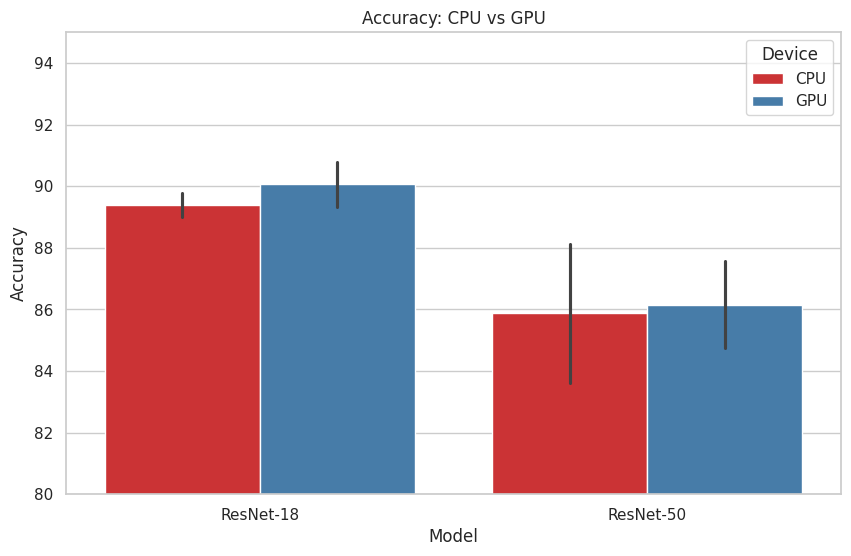

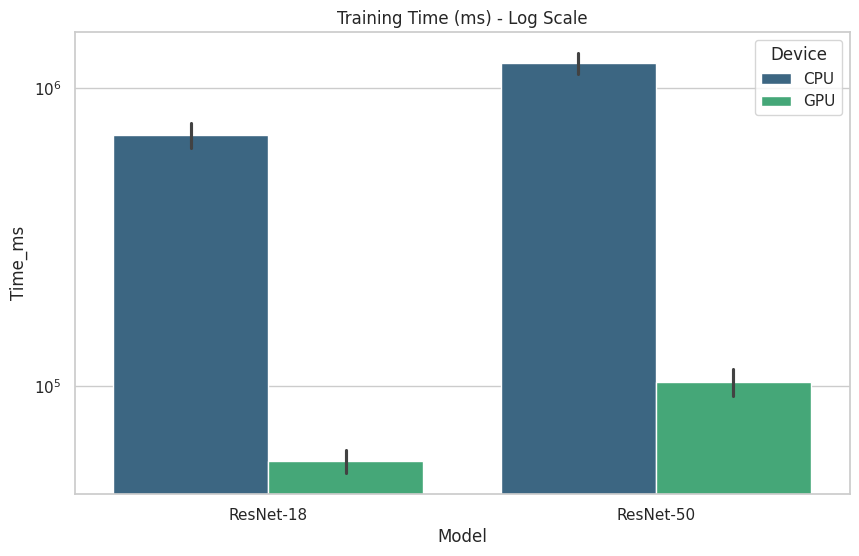

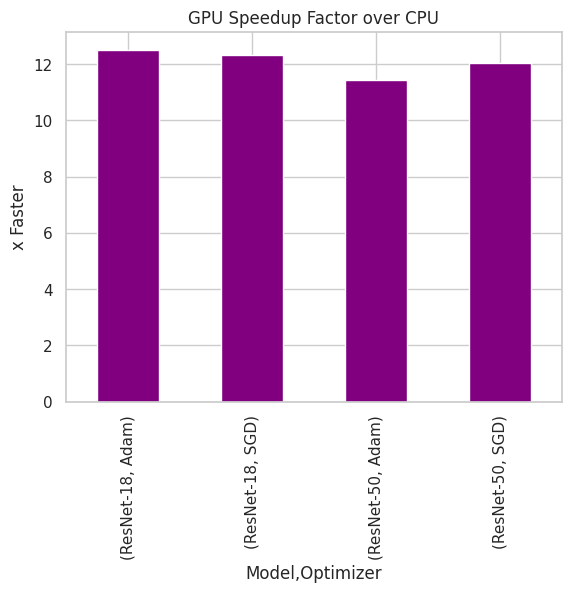

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load and standardize
cpu = pd.read_csv('cpu_summary.csv').rename(columns={'Epoch_Time_ms': 'Time_ms', 'Accuracy': 'Accuracy'})
cpu['Device'] = 'CPU'
gpu = pd.read_csv('gpu_summary.csv').rename(columns={'Train_Time_ms': 'Time_ms', 'Test_Accuracy': 'Accuracy', 'FLOPs': 'GFLOPs'})
gpu['GFLOPs'] = gpu['GFLOPs'] / 1e9
gpu['Device'] = 'GPU'

combined = pd.concat([cpu, gpu])

# Plot 1: Accuracy Comparison
plt.figure(figsize=(10, 6))
sns.barplot(data=combined, x='Model', y='Accuracy', hue='Device', palette='Set1')
plt.title('Accuracy: CPU vs GPU')
plt.ylim(80, 95)
plt.savefig('accuracy_comparison.png')

# Plot 2: Training Time (Log Scale)
plt.figure(figsize=(10, 6))
sns.barplot(data=combined, x='Model', y='Time_ms', hue='Device', palette='viridis')
plt.yscale('log')
plt.title('Training Time (ms) - Log Scale')
plt.savefig('time_comparison.png')

# Plot 3: GPU Speedup Factor
speedup = combined.pivot_table(index=['Model', 'Optimizer'], columns='Device', values='Time_ms')
speedup['Factor'] = speedup['CPU'] / speedup['GPU']
speedup.plot(kind='bar', y='Factor', color='purple', legend=False)
plt.title('GPU Speedup Factor over CPU')
plt.ylabel('x Faster')
plt.savefig('speedup_factor.png')

In [17]:
import pandas as pd
df = pd.read_csv('cpu_summary.csv')
df

,Model,Optimizer,Accuracy,Epoch_Time_ms,GFLOPs
0,ResNet-18,SGD,88.992857,6.300188e+05,0.071330
1,ResNet-18,Adam,89.778571,7.637201e+05,0.071330
2,ResNet-50,SGD,83.621429,1.112305e+06,0.165924
3,ResNet-50,Adam,88.121429,1.304599e+06,0.165924


In [18]:
import pandas as pd
df = pd.read_csv('gpu_summary.csv')
df

,Compute,Model,Optimizer,Test_Accuracy,Train_Time_ms,FLOPs
0,cuda,ResNet-18,SGD,89.328571,51046.825886,71329792
1,cuda,ResNet-18,Adam,90.792857,60977.228260,71329792
2,cuda,ResNet-50,SGD,84.735714,92309.535027,165923840
3,cuda,ResNet-50,Adam,87.564286,114125.391674,165923840


Loading mnist_784...
Training GPU Model: mnist_784 | rbf_C1.0
Training GPU Model: mnist_784 | rbf_C10.0
Training GPU Model: mnist_784 | poly_C1.0_D3
Training GPU Model: mnist_784 | poly_C0.1_D2
Loading Fashion-MNIST...
Training GPU Model: Fashion-MNIST | rbf_C1.0
Training GPU Model: Fashion-MNIST | rbf_C10.0
Training GPU Model: Fashion-MNIST | poly_C1.0_D3
Training GPU Model: Fashion-MNIST | poly_C0.1_D2


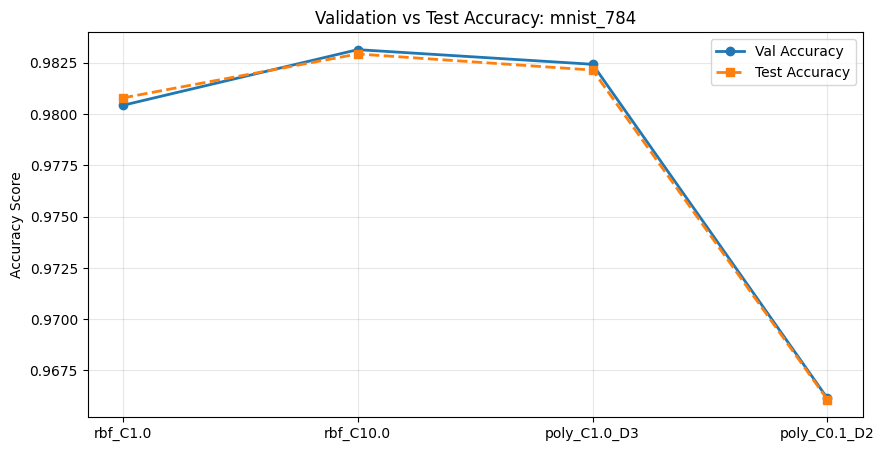

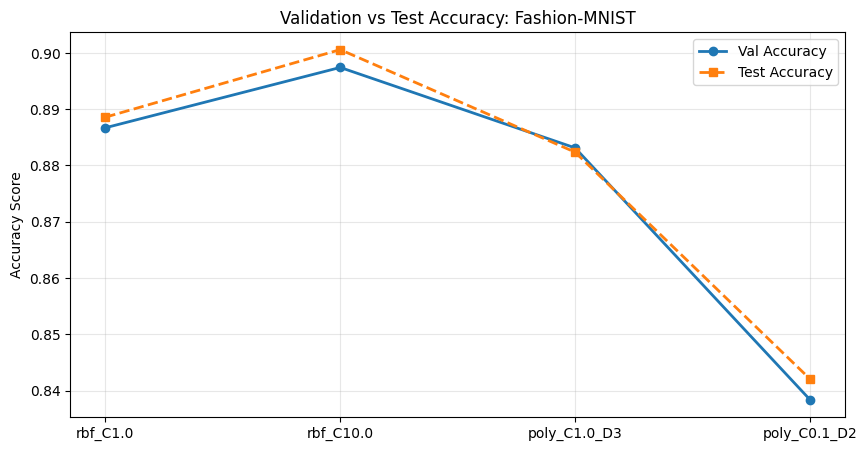

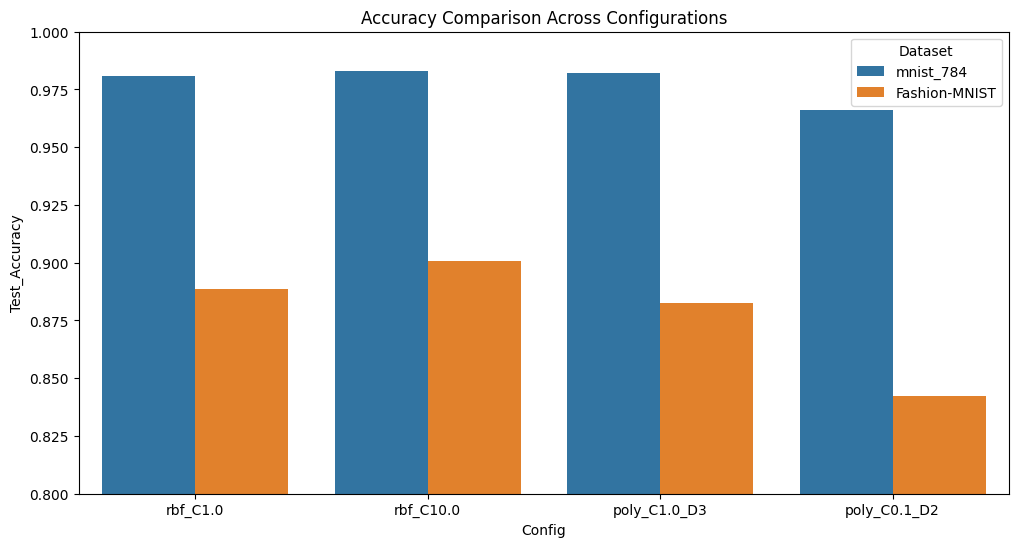

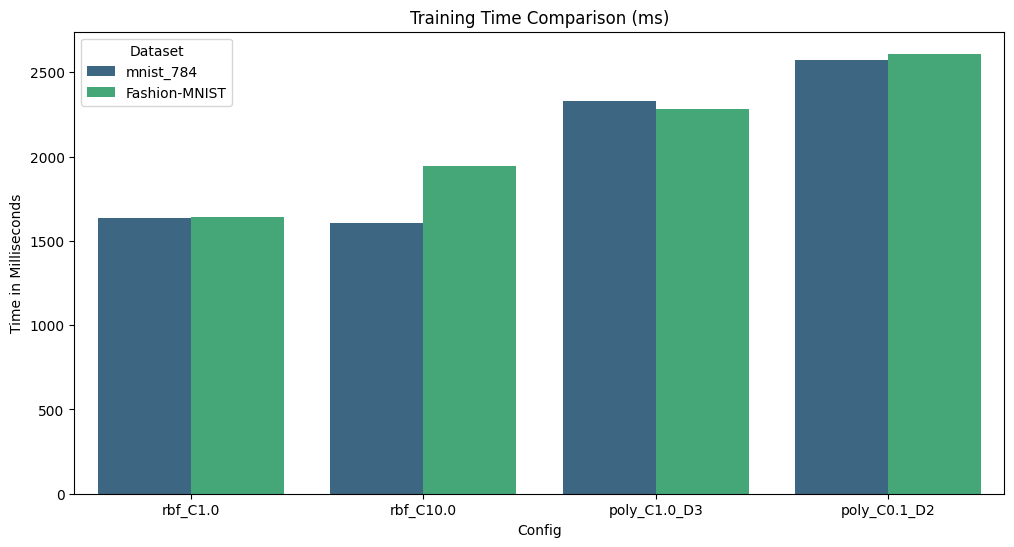

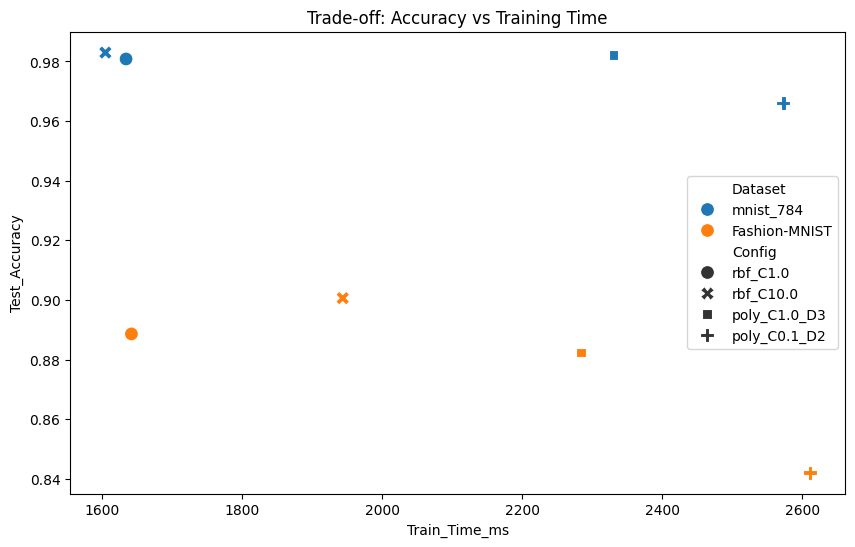


--- Final Report ---
         Dataset        Config  Val_Accuracy  Test_Accuracy  Train_Time_ms
0      mnist_784      rbf_C1.0      0.980426       0.980787    1634.625098
1      mnist_784     rbf_C10.0      0.983140       0.982930    1605.124790
2      mnist_784  poly_C1.0_D3      0.982426       0.982144    2330.474104
3      mnist_784  poly_C0.1_D2      0.966138       0.966074    2572.722315
0  Fashion-MNIST      rbf_C1.0      0.886698       0.888579    1642.310248
1  Fashion-MNIST     rbf_C10.0      0.897414       0.900579    1943.890336
2  Fashion-MNIST  poly_C1.0_D3      0.883126       0.882366    2283.517289
3  Fashion-MNIST  poly_C0.1_D2      0.838405       0.842083    2610.725662

Models saved in: /kaggle/working/models
Plots saved in: /kaggle/working/plots


In [ ]:
import os
import time
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cuml
from cuml.svm import SVC
from cuml.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.datasets import fetch_openml

# Create separate directories for organization
model_dir = "/kaggle/working/models"
plot_dir = "/kaggle/working/plots"
os.makedirs(model_dir, exist_ok=True)
os.makedirs(plot_dir, exist_ok=True)

def run_svm_gpu_experiment(dataset_name):
    print(f"Loading {dataset_name}...")
    X, y = fetch_openml(dataset_name, version=1, return_X_y=True, as_frame=False)
    X = (X / 255.0).astype(np.float32)
    y = y.astype(np.int32)

    X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=42)
    X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.6667, random_state=42)

    pca = PCA(n_components=80)
    X_train_pca = pca.fit_transform(X_train)
    X_val_pca = pca.transform(X_val)
    X_test_pca = pca.transform(X_test)

    configs = [
        {'kernel': 'rbf', 'C': 1.0, 'gamma': 'scale'},
        {'kernel': 'rbf', 'C': 10.0, 'gamma': 'auto'},
        {'kernel': 'poly', 'C': 1.0, 'degree': 3},
        {'kernel': 'poly', 'C': 0.1, 'degree': 2}
    ]

    results = []

    for config in configs:
        conf_name = f"{config['kernel']}_C{config['C']}"
        if 'degree' in config: conf_name += f"_D{config['degree']}"

        print(f"Training GPU Model: {dataset_name} | {conf_name}")
        start = time.perf_counter()
        model = SVC(**config)
        model.fit(X_train_pca, y_train)
        end = time.perf_counter()

        train_time_ms = (end - start) * 1000

        val_acc = accuracy_score(y_val, model.predict(X_val_pca))
        test_acc = accuracy_score(y_test, model.predict(X_test_pca))

        # Save model separately in the model directory
        torch.save(model, os.path.join(model_dir, f"{dataset_name}_{conf_name}.pth"))

        results.append({
            'Dataset': dataset_name,
            'Config': conf_name,
            'Val_Accuracy': val_acc,
            'Test_Accuracy': test_acc,
            'Train_Time_ms': train_time_ms
        })

    return pd.DataFrame(results)

mnist_df = run_svm_gpu_experiment('mnist_784')
fmnist_df = run_svm_gpu_experiment('Fashion-MNIST')
full_results = pd.concat([mnist_df, fmnist_df])

# GRAPH 1: Accuracy Trends (Line Plot) - Saved to plot_dir
for d_name in ['mnist_784', 'Fashion-MNIST']:
    plt.figure(figsize=(10, 5))
    subset = full_results[full_results['Dataset'] == d_name]
    plt.plot(subset['Config'], subset['Val_Accuracy'], marker='o', label='Val Accuracy', linewidth=2)
    plt.plot(subset['Config'], subset['Test_Accuracy'], marker='s', label='Test Accuracy', linestyle='--', linewidth=2)
    plt.title(f'Validation vs Test Accuracy: {d_name}')
    plt.ylabel('Accuracy Score')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.savefig(os.path.join(plot_dir, f"{d_name}_accuracy_trends.png"))
    plt.show()

# GRAPH 2: Accuracy Comparison (Bar Plot) - Saved to plot_dir
plt.figure(figsize=(12, 6))
sns.barplot(data=full_results, x='Config', y='Test_Accuracy', hue='Dataset')
plt.title('Accuracy Comparison Across Configurations')
plt.ylim(0.8, 1.0)
plt.savefig(os.path.join(plot_dir, "test_accuracy_bar.png"))
plt.show()

# GRAPH 3: Training Time Comparison (Bar Plot) - Saved to plot_dir
plt.figure(figsize=(12, 6))
sns.barplot(data=full_results, x='Config', y='Train_Time_ms', hue='Dataset', palette="viridis")
plt.title('Training Time Comparison (ms)')
plt.ylabel('Time in Milliseconds')
plt.savefig(os.path.join(plot_dir, "train_time_bar.png"))
plt.show()

# GRAPH 4: Accuracy vs Time (Scatter Plot) - Saved to plot_dir
plt.figure(figsize=(10, 6))
sns.scatterplot(data=full_results, x='Train_Time_ms', y='Test_Accuracy', hue='Dataset', style='Config', s=100)
plt.title('Trade-off: Accuracy vs Training Time')
plt.savefig(os.path.join(plot_dir, "accuracy_vs_time.png"))
plt.show()

# Save final CSV summary in the main directory
full_results.to_csv("/kaggle/working/results_summary.csv", index=False)

print("\n--- Final Report ---")
print(full_results)
print(f"\nModels saved in: {model_dir}")
print(f"Plots saved in: {plot_dir}")